In [37]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2_contingency
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from functools import reduce
from scipy.stats import ks_2samp
import numpy as np



# import matplotlib as mpl
# mpl.rcParams["font.family"] = "Avenir"

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

In [38]:
cell_ids = np.arange(0, 20)
carrier = 1000
beat = 5
frequency = 5
amplitudes_all = [-1, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
amplitudes_selected = [-1, 0.5, 0.9]
synapse_cols = [f"Synapse{idx}" for idx in range(0, 10)]
dendritic_spike_threshold = 20

stimulations = dict()
for amplitude in amplitudes_all:
  if amplitude == -1:
    stim = "noTI"
    stimulations[ stim ] = "No tTIS"
  else:
    stim = f"{carrier}_{beat}_{amplitude}"
    stimulations[ stim ] = f"{amplitude * 100:.0f}%"
  
selected_stimulations = { stim: label for stim, label in stimulations.items() if stim in [f"{carrier}_{beat}_{amp}" for amp in amplitudes_selected] or stim == "noTI" }

In [39]:
# optional: convert to stars
def p_to_stars(p):
  if p < 1e-4:
    return "****"
  elif p < 1e-3:
    return "***"
  elif p < 1e-2:
    return "**"
  elif p < 0.05:
    return "*"
  else:
    return "ns"

In [57]:
def categorize(w):
  if w > 0.1: return "LTP"
  if w < 0.1: return "LTD"
  return "no change"

  # if w > 0.7:
  #   return "strong LTP"
  # elif 0.4 < w <= 0.7:
  #   return "medium LTP"
  # elif 0.1 < w <= 0.4:
  #   return "weak LTP"
  # elif w == 0.1:
  #   return "no change"
  # else:
  #   return "LTD"

order = [
  "LTD",
  "no change",
  "LTP"
  # "weak LTP",
  # "medium LTP",
  # "strong LTP"
]

palette = {
  "LTD": "#0D0887",
  "no change": "#CCCCCC",
  "LTP": "#E16462"
  # "weak LTP": "#FCA636",
  # "medium LTP": "#E16462",
  # "strong LTP": "#B12A90"
}

## Proportion of potentiated / depressed synapses

In [41]:
final_weights = list()
for cell_id in cell_ids:
  for stim in stimulations.keys():
    filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/synapse_weights.csv"
    synapse_weights = pd.read_csv(filename, index_col = 0)
    weights = synapse_weights[synapse_cols].iloc[-1].tolist()
    
    final = pd.DataFrame({
      "Amplitude": stimulations[ stim ],
      "Weight": weights,
      "SynapseID": [ f"{synapse}_{cell_id}" for synapse in synapse_cols ],
      "Category": [ categorize(w) for w in weights ]
    })

    final["Category"] = pd.Categorical(final["Category"], categories = order, ordered = True)

    final_weights.append(final)

final_weights = pd.concat(final_weights)
final_weights

,Amplitude,Weight,SynapseID,Category
0,No tTIS,0.199465,Synapse0_0,LTP
1,No tTIS,0.452394,Synapse1_0,LTP
2,No tTIS,0.080258,Synapse2_0,LTD
3,No tTIS,0.714719,Synapse3_0,LTP
4,No tTIS,0.468787,Synapse4_0,LTP
...,...,...,...,...
5,90%,0.231653,Synapse5_19,LTP
6,90%,0.337277,Synapse6_19,LTP
7,90%,0.412640,Synapse7_19,LTP
8,90%,0.999348,Synapse8_19,LTP


In [42]:
counts = (
  final_weights
  .groupby(["Amplitude", "Category"], observed = True)
  .size()
  .unstack(fill_value=0)
)

no_ti = counts.loc["No tTIS"].values

final_weight_category_p = {}

for condition in counts.index:
  if condition == "No tTIS":
    continue
  
  other = counts.loc[condition].values
  table = np.vstack([no_ti, other])
  
  chi2, p, dof, expected = chi2_contingency(table)
  final_weight_category_p[condition] = p

final_weight_category_stars = { condition: p_to_stars(p) for condition, p in final_weight_category_p.items() }
final_weight_category_stars

{'10%': 'ns',
 '20%': 'ns',
 '30%': 'ns',
 '40%': '*',
 '50%': '**',
 '60%': '**',
 '70%': '***',
 '80%': '****',
 '90%': '****'}

In [43]:
# Somatic firing frequency
somatic_firing = list()
for cell_id in cell_ids:
  for stim in stimulations.keys():      
    filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/spike_frequency.csv"
    n_spikes = len(pd.read_csv(filename, index_col = 0))
    spike_freq = n_spikes / 10

    somatic_firing.append(
      pd.DataFrame({
        "Amplitude": [stimulations[ stim ]],
        "Frequency": [spike_freq]
      })
    )

somatic_firing = pd.concat(somatic_firing)

# Dendritic firing frequency
dendritic_firing = list()
for stim in stimulations.keys():
  print(f"Processing stimulation: {stim}")
  spike_counts = []
  for cell_id in cell_ids:
    filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/synapse_voltage.csv"
    synapse_voltage = pd.read_csv(filename, index_col=0)

    syn_v = synapse_voltage[synapse_cols].to_numpy()

    spikes = (syn_v[:-1, :] >= dendritic_spike_threshold) & (syn_v[1:, :] < dendritic_spike_threshold)
    counts = np.sum(spikes, axis=0)

    spike_counts.extend(counts.tolist())

  dendritic_firing.append(
    pd.DataFrame({
      "Amplitude": stimulations[ stim ],
      "Frequency": np.array(spike_counts) / 10
    })
  )

dendritic_firing = pd.concat(dendritic_firing)

Processing stimulation: noTI
Processing stimulation: 1000_5_0.1
Processing stimulation: 1000_5_0.2
Processing stimulation: 1000_5_0.3
Processing stimulation: 1000_5_0.4
Processing stimulation: 1000_5_0.5
Processing stimulation: 1000_5_0.6
Processing stimulation: 1000_5_0.7
Processing stimulation: 1000_5_0.8
Processing stimulation: 1000_5_0.9


In [44]:
soma_0 = somatic_firing[ somatic_firing.Amplitude == "No tTIS" ].Frequency.mean()
soma_0_sd = somatic_firing[ somatic_firing.Amplitude == "No tTIS" ].Frequency.std()
soma_50 = somatic_firing[ somatic_firing.Amplitude == "50%" ].Frequency.mean()
soma_50_sd = somatic_firing[ somatic_firing.Amplitude == "50%" ].Frequency.std()
soma_60 = somatic_firing[ somatic_firing.Amplitude == "60%" ].Frequency.mean()
soma_60_sd = somatic_firing[ somatic_firing.Amplitude == "60%" ].Frequency.std()
soma_90 = somatic_firing[ somatic_firing.Amplitude == "90%" ].Frequency.mean()
soma_90_sd = somatic_firing[ somatic_firing.Amplitude == "90%" ].Frequency.std()

print(f"Somatic firing frequency - No tTIS: {soma_0:.2f} Hz +- {soma_0_sd:.2f} Hz")
print(f"Somatic firing frequency - 50%: {soma_50:.2f} Hz +- {soma_50_sd:.2f} Hz")
print(f"Somatic firing frequency - 60%: {soma_60:.2f} Hz +- {soma_60_sd:.2f} Hz")
print(f"Somatic firing frequency - 90%: {soma_90:.2f} Hz +- {soma_90_sd:.2f} Hz")

dendrite_0 = dendritic_firing[ dendritic_firing.Amplitude == "No tTIS" ].Frequency.mean()
dendrite_0_sd = dendritic_firing[ dendritic_firing.Amplitude == "No tTIS" ].Frequency.std()
dendrite_50 = dendritic_firing[ dendritic_firing.Amplitude == "50%" ].Frequency.mean()
dendrite_50_sd = dendritic_firing[ dendritic_firing.Amplitude == "50%" ].Frequency.std()
dendrite_60 = dendritic_firing[ dendritic_firing.Amplitude == "60%" ].Frequency.mean()
dendrite_60_sd = dendritic_firing[ dendritic_firing.Amplitude == "60%" ].Frequency.std()
dendrite_90 = dendritic_firing[ dendritic_firing.Amplitude == "90%" ].Frequency.mean()
dendrite_90_sd = dendritic_firing[ dendritic_firing.Amplitude == "90%" ].Frequency.std()

print(f"Dendritic firing frequency - No tTIS: {dendrite_0:.2f} Hz +- {dendrite_0_sd:.2f} Hz")
print(f"Dendritic firing frequency - 50%: {dendrite_50:.2f} Hz +- {dendrite_50_sd:.2f} Hz")
print(f"Dendritic firing frequency - 60%: {dendrite_60:.2f} Hz +- {dendrite_60_sd:.2f} Hz")
print(f"Dendritic firing frequency - 90%: {dendrite_90:.2f} Hz +- {dendrite_90_sd:.2f} Hz")

Somatic firing frequency - No tTIS: 0.18 Hz +- 0.42 Hz
Somatic firing frequency - 50%: 0.93 Hz +- 1.36 Hz
Somatic firing frequency - 60%: 1.13 Hz +- 1.52 Hz
Somatic firing frequency - 90%: 3.08 Hz +- 2.67 Hz
Dendritic firing frequency - No tTIS: 1.17 Hz +- 1.91 Hz
Dendritic firing frequency - 50%: 2.01 Hz +- 2.51 Hz
Dendritic firing frequency - 60%: 2.14 Hz +- 2.58 Hz
Dendritic firing frequency - 90%: 4.07 Hz +- 3.46 Hz


In [45]:
def expand_time(original, max_time = 10_000, time_step = 0.025):
    original["Time"] = (original["Time"] / time_step).round() * time_step
    original = original.sort_values("Time")

    new_time = np.arange(0, max_time + time_step, time_step)

    expanded = pd.DataFrame({ "Time": new_time })
    expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

    return expanded

synapse_weights = dict()
for stim in selected_stimulations.keys():
  print(f"Processing stimulation: {stim}")
  dfs = []
  for cell_id in cell_ids:
    filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/synapse_weights.csv"
    
    df = pd.read_csv(filename, index_col = 0)
    df = expand_time(df).set_index("Time")

    # make synapse columns unique per cell
    syn_cols = [c for c in df.columns if c != "Time"]
    df = df.rename(columns={c: f"{c}_cell{cell_id}" for c in syn_cols})

    dfs.append(df)

  # merge all on Time
  synapse_weights[ stim ] = reduce(lambda left, right: pd.merge(left, right, on="Time", how="inner"), dfs)

Processing stimulation: noTI
Processing stimulation: 1000_5_0.5
Processing stimulation: 1000_5_0.9


In [46]:
def plot_weight_heatmap(ax, df, categorize, palette, show_cbar=False, show_ylabel = True):
    heatmap_df = df.T.copy()

    final_weights = heatmap_df.iloc[:, -1]
    heatmap_df = heatmap_df.loc[final_weights.sort_values(ascending=False).index]
    final_weights = heatmap_df.iloc[:, -1]

    categories = final_weights.apply(categorize)
    row_colors = categories.map(palette)

    cmap = LinearSegmentedColormap.from_list(
        "custom_weights",
        [
            (0.0, "#0D0887"),
            (0.1, "#CCCCCC"),
            (0.2, "#FCA636"),
            (0.7, "#E16462"),
            (1.0, "#B12A90")
        ]
    )

    im = ax.imshow(
        heatmap_df.values,
        aspect="auto",
        cmap=cmap,
        vmin=0,
        vmax=1
    )

    # row colors on right
    for i, color in enumerate(row_colors):
        ax.add_patch(
            plt.Rectangle(
                (heatmap_df.shape[1], i),
                0.5,
                1,
                color=color,
                transform=ax.transData,
                clip_on=False
            )
        )

    # x ticks
    time_values = heatmap_df.columns.values / 1000
    ticks = np.linspace(0, len(time_values) - 1, 6).astype(int)
    labels = np.round(np.linspace(time_values[0], time_values[-1], 6), 1)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)

    ax.set_yticks([])
    if show_ylabel:
      ax.set_ylabel("Synapse")

    ax.set_xlabel("Time (s)")

    if show_cbar:
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Weight")

    return im

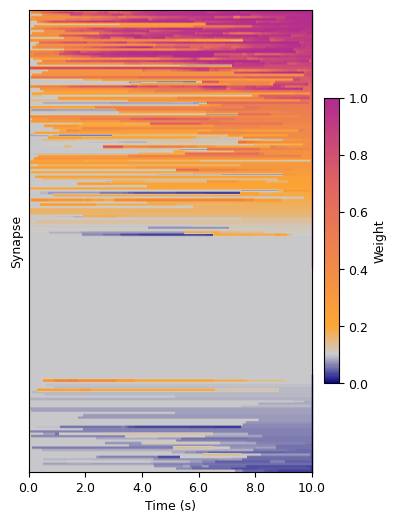

In [47]:
fig, ax = plt.subplots(figsize=(4, 6))
plot_weight_heatmap(ax, synapse_weights[f"{carrier}_{beat}_0.5"], categorize, palette, show_cbar=True)

In [48]:
change_in_weights = dict()
for stim in selected_stimulations.keys():
  weights = synapse_weights[ stim ].to_numpy()

  # Calculate weight change average
  change = weights - 0.1
  change = np.abs(change)
  mean_change = change.mean(axis = 1)

  errors = change.std(axis = 1) / np.sqrt(change.shape[1])

  change_in_weights[ stim ] = pd.DataFrame({
    "Time": synapse_weights[ stim ].index / 1000,
    "Change": mean_change,
    "Error": errors
  })

In [49]:
def plot_weight_change(ax, change_in_weights):
  ax.plot(
    change_in_weights.Time,
    change_in_weights.Change,
    linewidth=0.5,
    color = "black"
  )

  ax.fill_between(
    change_in_weights.Time,
    change_in_weights.Change - change_in_weights.Error,
    change_in_weights.Change + change_in_weights.Error,
    alpha=0.25,
    color = "black"
  )

  ax.set_xlabel("Time, s")
  ax.set_ylabel(r"$\Delta$ weight")

  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  
  ax.set_ylim(0, 0.3)
  ax.grid(alpha = 0.5)

In [50]:
def plot_weight_histograms(axs, final_weights):
    bin_width = 0.05
    bins = np.arange(0, 0.9 + bin_width, bin_width)

    ref_key = "noTI"
    ref_weights = final_weights[ref_key]

    for ax, stimulation in zip(axs, final_weights.keys()):
        weights = final_weights[stimulation]

        ax.hist(
            weights,
            edgecolor="black",
            facecolor="black",
            alpha=0.25,
            bins=bins,
            linewidth=0.5
        )

        ax.set_xlabel(r"$\Delta$ weight", fontsize=9)

        if stimulation != ref_key:
            _, p_val = ks_2samp(ref_weights, weights)
            stars = p_to_stars(p_val)
            ax.set_title(
                f"KS p = {p_val:.2e} ({stars})",
            )

        # clean style
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.grid(alpha = 0.5)

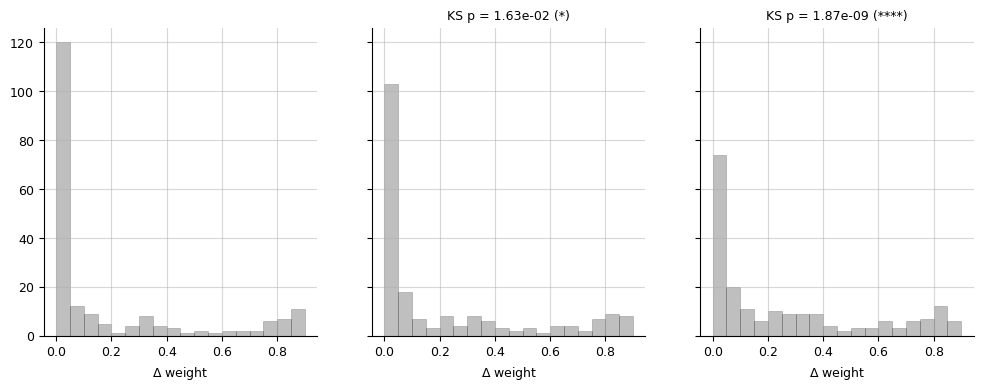

In [51]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
weight_change = { stim: np.abs(final_weights[final_weights["Amplitude"] == label]["Weight"].values - 0.1) for stim, label in selected_stimulations.items() }
plot_weight_histograms(axs, weight_change)

In [52]:
def calculate_monotonicity_index(weight_matrix, floor=0.0, ceiling=1.0, epsilon=0.01):
    """
    Calculates normalized monotonicity index for synapses.
    
    Parameters:
    - weight_matrix: np.array of shape (synapses, time)
    - floor: The minimum possible weight (default 0.0)
    - ceiling: The maximum possible weight (default 1.0)
    - epsilon: How close to the ceiling before we consider it "saturated"
    """
    n_synapses, n_time = weight_matrix.shape
    indices = []

    for i in range(n_synapses):
        weights = weight_matrix[i, :]
        
        # 1. Truncate at EITHER boundary (Floor or Ceiling)
        # Check where weight is >= (1 - eps) OR <= (0 + eps)
        at_boundary = np.where((weights >= (ceiling - epsilon)) | 
                               (weights <= (floor + epsilon)))[0]
        
        if len(at_boundary) > 0:
            end_idx = at_boundary[0] + 1
            active_weights = weights[:end_idx]
        else:
            active_weights = weights

        # 2. Metric calculation
        # If the trace is too short to have a diff, we assume it's monotonic
        if len(active_weights) < 2:
            indices.append(1.0)
            continue

        deltas = np.diff(active_weights)
        net_displacement = np.abs(active_weights[-1] - active_weights[0])
        total_path = np.sum(np.abs(deltas))
        
        if total_path < 1e-9: # Precision handling for very small movements
            m_index = 1.0
        else:
            m_index = net_displacement / total_path
            
        indices.append(m_index)
        
    return np.array(indices)

In [53]:
def moving_average(y, window):
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode="same")

def plot_weight_change(change_in_weights, label, color, window, ax):
  from scipy.ndimage import gaussian_filter1d
  # smooth
  smoothed_change = moving_average(change_in_weights.Change.values, window)
  smoothed_error = moving_average(change_in_weights.Error.values, window)

  last_index = len(smoothed_change) - int(window / 2) - 1
  smoothed_change[ last_index:len(smoothed_change) ] = smoothed_change[ last_index ]
  smoothed_error[ last_index:len(smoothed_error) ] = smoothed_error[ last_index ]

  ax.plot(
    change_in_weights.Time,
    smoothed_change,
    linewidth = 0.5,
    label = label,
    color = color
  )

  ax.fill_between(
    change_in_weights.Time,
    smoothed_change - smoothed_error,
    smoothed_change + smoothed_error,
    alpha = 0.5,
    color = color,
    edgecolor = None
  )

  ax.set_xlabel("Time, s")
  ax.set_ylabel(r"$\Delta$ weight")

  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  
  ax.set_ylim(0, 0.3)
  ax.grid(alpha = 0.5)
  ax.autoscale(False)

In [54]:
monotonicity = dict()
for stim in selected_stimulations.keys():
  results = calculate_monotonicity_index(synapse_weights[stim].to_numpy().T)
  monotonicity[stim] = results

In [55]:
def plot_violin_plots(data, colors, label, test, show_stat, ax):
  labels = list(data.keys())
  groups = [data[stim] for stim in labels]

  ax.grid(alpha = 0.5)

  parts = ax.violinplot(
    groups,
    showmeans=False,
    showmedians=False,
    showextrema=False
  )

  for body, key in zip(parts["bodies"], data.keys()):
    body.set_facecolor(colors[key])
    body.set_facecolor(colors[key])
    body.set_linewidth(1)
    body.set_alpha(0.5)

  corrected_labels = [selected_stimulations[s] if selected_stimulations[s] == "No tTIS" else f"{selected_stimulations[s]} tTIS" for s in labels]
  ax.set_xticks(range(1, len(labels) + 1))
  ax.set_xticklabels(corrected_labels)

  # stats vs No TI
  ref_idx = labels.index("noTI")

  y_max = max([g.max() for g in groups])
  y_offset = 0.05 * y_max

  for i in range(len(groups)):
    if i == ref_idx:
      continue

    if test == "t-test":
      stat, p_val = stats.ttest_ind(groups[ref_idx], groups[i])
    if test == "KS":
      stat, p_val = ks_2samp(groups[ref_idx], groups[i])
    if test == "mannwhitney":
      stat, p_val = stats.mannwhitneyu(groups[ref_idx], groups[i], alternative="two-sided")
    
    stars = p_to_stars(p_val)

    x = i + 1
    y = groups[i].max() + y_offset

    if show_stat and test == "KS":
      full = f"D = {stat}\n{stars}"
      ax.text(x, y, full, ha="center", va="bottom", fontsize = 8)
    else:
      ax.text(x, y, stars, ha="center", va="bottom", fontsize = 8)

  ax.set_ylim(top=y_max + 5 * y_offset)

  for spine in ["bottom", "left"]:
    ax.spines[spine].set_visible(True)

  for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

  ax.set_ylabel(label)

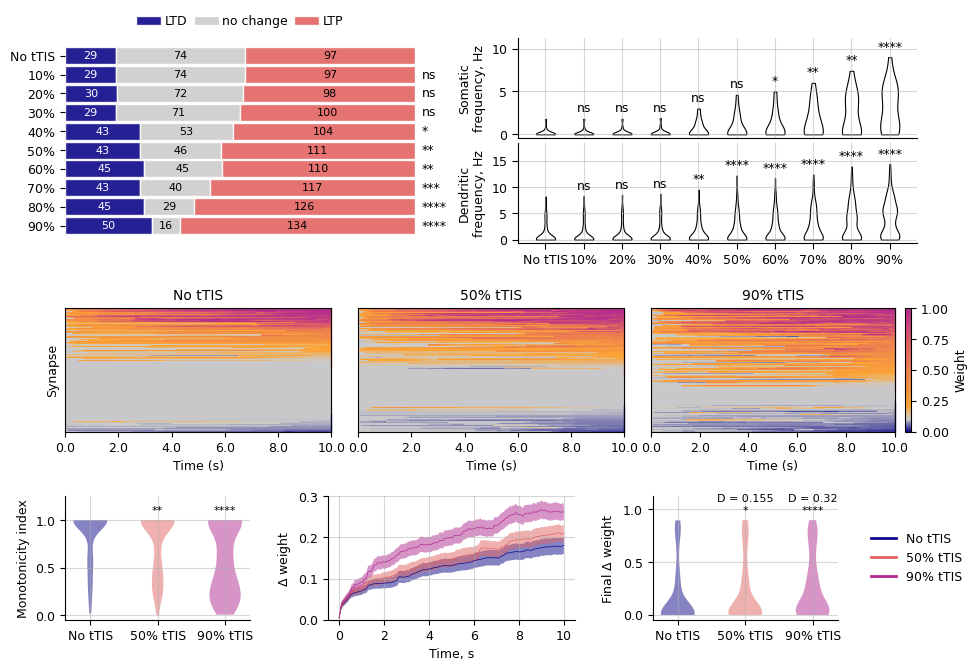

In [76]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.ticker import PercentFormatter

fig = plt.figure(figsize=(11, 10))

outer_gs = gridspec.GridSpec(
    4, 1,
    height_ratios=[1, 0.6, 0.6, 0.6],
    hspace=0.45
)

# --- FIRST ROW: 2 panels, make first wider ---

inner_gs_1 = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=outer_gs[0],
    width_ratios=[1.4, 1.6],
    wspace = 0.275
)

ax = fig.add_subplot(inner_gs_1[0])

group_counts = (
  final_weights
  .groupby(["Amplitude", "Category"], observed = True)
  .size()
  .reset_index(name = "Count")
)

group_props = (
  group_counts
  .groupby("Amplitude", group_keys=False)
  .apply(lambda df: df.assign(Proportion = df["Count"] / df["Count"].sum()))
)

order = [
  "LTD",
  "no change",
  "LTP"
  # "weak LTP",
  # "medium LTP",
  # "strong LTP"
]

pivot = group_props.pivot(index = "Amplitude", columns = "Category", values = "Proportion")
pivot = pivot[order].fillna(0)

# reorder rows: No TI, Pure carrier at top
priority = ["No tTIS"]
new_index = priority + [i for i in pivot.index if i not in priority]
pivot = pivot.loc[new_index]

y_pos = range(len(pivot.index))
left = [0] * len(pivot.index)

for group in order:
    values = pivot[group].values
    bars = ax.barh(
        y_pos,
        values,
        left=left,
        color=palette[group],
        edgecolor="white",
        linewidth=1,
        height=0.9,
        label=group,
        alpha = 0.9
    )
    left = [l + v for l, v in zip(left, values)]

    # annotate percentages

    for bar, v in zip(bars, values):
        if v > 0:  # avoid clutter for zero values
            if group == "LTD":
                text_col = "white"
            else:
                text_col = "black"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{v * 200:.0f}",
                ha="center",
                va="center",
                fontsize=8,
                c = text_col
            )

# place significance on the RIGHT side instead of inside tick labels

ax.set_yticks(y_pos)
ax.set_yticklabels(pivot.index)

# add text on the right
x_max = 1

for y, label in zip(y_pos, pivot.index):
    if label == "No tTIS":
        continue
    
    star = final_weight_category_stars.get(label, "ns")
    
    ax.text(
        x_max * 1.02,  # slightly outside bars
        y,
        star,
        va="center",
        ha="left",
        fontsize=9
    )

# extend xlim so text is visible
ax.set_xlim(0, x_max * 1.15)

ax.set_xlabel("")
ax.tick_params(bottom = False, labelbottom = False)
ax.set_xlim(0, 1)
# ax.xaxis.set_major_formatter(PercentFormatter(1.0))

# invert so first rows appear at top
ax.invert_yaxis()

ax.legend(
    loc="upper center",
    ncol=len(order),
    frameon=False,
    bbox_to_anchor=(0.5, 1.15),
    columnspacing=0.5,   # horizontal space between entries
    handletextpad=0.3,   # space between marker and text
    borderaxespad=0.2    # space between legend and axes
)

ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

#################### FIRING FREQUENCY


inner_gs_1_right = inner_gs_1[1].subgridspec(2, 1, hspace=0.05)

ax_right_top = fig.add_subplot(inner_gs_1_right[0])
ax_right_bottom = fig.add_subplot(inner_gs_1_right[1], sharex=ax_right_top)

################## Somatic firing frequency

frequency = somatic_firing
grouped = list(frequency.groupby("Amplitude"))
labels = [name for name, _ in grouped]
groups = [g["Frequency"].values for _, g in grouped]

# reorder
priority = ["No tTIS"]
order = priority + [l for l in labels if l not in priority]

label_to_group = dict(zip(labels, groups))
labels = order
groups = [label_to_group[l] for l in labels]

# violin plot
vp = ax_right_top.violinplot(
    groups,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# style violins
for body in vp["bodies"]:
    body.set_facecolor("white")
    body.set_edgecolor("black")
    body.set_linewidth(0.8)
    body.set_alpha(1)

# ticks
# ax_right_top.set_xticks(range(1, len(labels) + 1))
# ax_right_top.set_xticklabels(labels)

ax_right_top.set_ylabel("Somatic\nfrequency, Hz")
ax_right_top.set_xlabel("")

ax_right_top.xaxis.set_ticks_position("bottom")
ax_right_top.yaxis.set_ticks_position("left")
ax_right_top.tick_params(axis="x", bottom=False, top=False, length=4)
ax_right_top.tick_params(axis="y", left=True, right=False, length=4)

# stats vs No tTIS
ref_idx = labels.index("No tTIS")

y_max = max([g.max() for g in groups])
y_offset = 0.05 * y_max

for i in range(len(groups)):
    if i == ref_idx:
        continue

    stat, p_val = stats.mannwhitneyu(groups[ref_idx], groups[i], alternative="two-sided")
    stars = p_to_stars(p_val)

    x = i + 1
    y = groups[i].max() + y_offset

    ax_right_top.text(x, y, stars, ha="center", va="bottom")

ax_right_top.set_ylim(top=y_max + 5 * y_offset)

for spine in ["bottom", "left"]:
    ax_right_top.spines[spine].set_visible(True)

for spine in ["top", "right"]:
    ax_right_top.spines[spine].set_visible(False)

ax_right_top.grid(alpha = 0.5)

####################### Dendritic firing frequency

frequency = dendritic_firing
grouped = list(frequency.groupby("Amplitude"))
labels = [name for name, _ in grouped]
groups = [g["Frequency"].values for _, g in grouped]

# reorder
priority = ["No tTIS"]
order = priority + [l for l in labels if l not in priority]

label_to_group = dict(zip(labels, groups))
labels = order
groups = [label_to_group[l] for l in labels]

# violin plot
vp = ax_right_bottom.violinplot(
    groups,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# style violins
for body in vp["bodies"]:
    body.set_facecolor("white")
    body.set_edgecolor("black")
    body.set_linewidth(0.8)
    body.set_alpha(1)

# ticks
ax_right_bottom.set_xticks(range(1, len(labels) + 1))
ax_right_bottom.set_xticklabels(labels)

ax_right_bottom.set_ylabel("Dendritic\nfrequency, Hz")
ax_right_bottom.set_xlabel("")

ax_right_bottom.xaxis.set_ticks_position("bottom")
ax_right_bottom.yaxis.set_ticks_position("left")
ax_right_bottom.tick_params(axis="x", bottom=True, top=False, length=4)
ax_right_bottom.tick_params(axis="y", left=True, right=False, length=4)

# stats vs No TI
ref_idx = labels.index("No tTIS")

y_max = max([g.max() for g in groups])
y_offset = 0.05 * y_max

for i in range(len(groups)):
    if i == ref_idx:
        continue

    stat, p_val = stats.mannwhitneyu(groups[ref_idx], groups[i], alternative="two-sided")
    stars = p_to_stars(p_val)

    x = i + 1
    y = groups[i].max() + y_offset

    ax_right_bottom.text(x, y, stars, ha="center", va="bottom")

ax_right_bottom.set_ylim(top=y_max + 5.5 * y_offset)

for spine in ["bottom", "left"]:
    ax_right_bottom.spines[spine].set_visible(True)

for spine in ["top", "right"]:
    ax_right_bottom.spines[spine].set_visible(False)

ax_right_bottom.grid(alpha = 0.5)

###################### HEATMAP

# ---- USE IN GRID (ROW 2) ----
# assume axes for row 2 already created: ax_r2_1, ax_r2_2, ax_r2_3

inner_gs_2 = gridspec.GridSpecFromSubplotSpec(
    1, 3,
    subplot_spec=outer_gs[1],
    wspace=0.1
)

ax_r2_1 = fig.add_subplot(inner_gs_2[0])
ax_r2_2 = fig.add_subplot(inner_gs_2[1])
ax_r2_3 = fig.add_subplot(inner_gs_2[2])

plot_weight_heatmap(ax_r2_1, synapse_weights[f"noTI"], categorize, palette, show_cbar=False, show_ylabel = True)
plot_weight_heatmap(ax_r2_2, synapse_weights[f"{carrier}_{beat}_0.5"], categorize, palette, show_cbar=False, show_ylabel = False)
plot_weight_heatmap(ax_r2_3, synapse_weights[f"{carrier}_{beat}_0.9"], categorize, palette, show_cbar=True, show_ylabel = False)

ax_r2_1.set_title("No tTIS", fontsize = 10)
ax_r2_2.set_title("50% tTIS", fontsize = 10)
ax_r2_3.set_title("90% tTIS", fontsize = 10)

################## Monotonicity index
inner_gs_3 = gridspec.GridSpecFromSubplotSpec(
    1, 4 ,
    subplot_spec=outer_gs[2],
    wspace=0.5,
    width_ratios=[0.9, 1.2, 0.9, 0.01]
)

ax_r3_1 = fig.add_subplot(inner_gs_3[1])
ax_r3_2 = fig.add_subplot(inner_gs_3[0])
ax_r3_3 = fig.add_subplot(inner_gs_3[2])
ax_r3_4 = fig.add_subplot(inner_gs_3[3])

colors = {
  "noTI": "#0D0887",
  f"{carrier}_{beat}_0.5": "#E16462",
  f"{carrier}_{beat}_0.9": "#B12A90"
}

for stimulation in selected_stimulations.keys():
  if stimulation != "noTI":
    label = f"{selected_stimulations[stimulation]} tTIS"
  else:
    label = selected_stimulations[stimulation]

  plot_weight_change(
    change_in_weights[stimulation],
    label = label,
    color = colors[stimulation],
    window = 2500,
    ax = ax_r3_1
  )

plot_violin_plots(monotonicity, colors, label = "Monotonicity index", test = "mannwhitney", show_stat = False, ax = ax_r3_2)

weight_change = { stim: np.abs(final_weights[final_weights["Amplitude"] == label]["Weight"].values - 0.1) for stim, label in selected_stimulations.items() }
plot_violin_plots(weight_change, colors, label = r"Final $\Delta$ weight", test = "KS", show_stat = True, ax = ax_r3_3)

### Only legend
ax_r3_4.axis("off")

# create legend with thicker lines and no frame
handles, labels = ax_r3_1.get_legend_handles_labels()

legend = ax_r3_4.legend(
    handles,
    labels,
    loc="center",
    frameon=False,
    handlelength=2
)

# increase line thickness in legend
for line in legend.get_lines():
    line.set_linewidth(2)

# plt.savefig("figure-results_poisson-1000-5.png", dpi=300, bbox_inches="tight")
plt.show()

In [234]:
(50 - 29) / 29
(134 - 97) / 97

0.38144329896907214

In [75]:
## Additional stuff

In [22]:
def read_spike_times(idx, rate, carrier = 1000, offset = 5, strength = 0.9, initial_weight = 0.1):
    global project
    
    if carrier is None:
        filename = f"noTI_{initial_weight}"
    else:
        filename = f"{carrier}_{offset}_{strength}_{initial_weight}"

    spike_times = pd.read_csv(
        f"../output/temporal-interference-1/{idx}/random_poisson/{rate}/{filename}/synapse_stimuli.csv",
        header = None
    )
    spike_times = spike_times.fillna('').values.tolist()
    spike_times = [[x for x in row if x != ""] for row in spike_times]

    return spike_times

In [23]:
idx = 0
rate = 5
initial_weight = 0.1

spike_times = read_spike_times(
    idx = idx,
    rate = rate,
    initial_weight = initial_weight,
    carrier = None
)

colors = {
    "No tTIS": "#0D0887",
    "0 Hz TI": "#B12A90",

    "5 Hz TI": "#E16462",
    "130 Hz TI": "#FCA636"
}

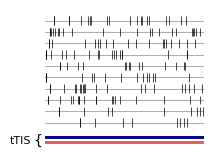

In [24]:
fig = plt.figure(figsize = (8.4, 14))

outer_gs = gridspec.GridSpec(9, 1, height_ratios = [1, 0.2, 2.5, 0.5, 0.7, 0.25, 0.7, 0.25, 0.7])

# --- A and B panels ---

inner_gs_1 = gridspec.GridSpecFromSubplotSpec(3, 4, subplot_spec = outer_gs[0], width_ratios = [0.1, 0.2, 0.11, 0.3], height_ratios = [0.9, 0.02, 0.02], hspace = 0.05)

### A

ax_a = fig.add_subplot(inner_gs_1[0, 1])

for i, spikes in enumerate(spike_times):
    ax_a.eventplot(spikes, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

ax_a.set_ylim(0, 11)
ax_a.set_yticks(np.arange(1, 11, 1))
ax_a.set_yticklabels([])
ax_a.tick_params(axis = "y", labelleft = False, which = "both", left = False)

ax_a.set_xlabel("")
ax_a.set_xlim(0, 3000)
ax_a.tick_params(axis = "x", labelbottom = False, which = "both", bottom = False)

ax_a.grid(True)
ax_a.xaxis.grid(False)
ax_a.yaxis.grid(True)

sns.despine(ax = ax_a, top = True, bottom = True, left = True, right = True)

# ax_a.set_title("Poisson synaptic inputs", y = 0.925)

################## The NO TI line

ax = fig.add_subplot(inner_gs_1[1, 1])

ax.axvspan(
    0,
    3000,
    color = colors["No tTIS"],
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax = fig.add_subplot(inner_gs_1[2, 1])

ax.axvspan(
    0,
    3000,
    color = colors["5 Hz TI"],
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(0.225, 0.78665, "tTIS", fontsize = 8, va = "center", ha = "center")
fig.text(0.245, 0.78665, "{", fontsize = 10, va = "center", ha = "center")

plt.savefig("figure-results_protocol-1000-5.png", dpi = 500, bbox_inches = "tight", transparent = True)

In [25]:
mean_var_noTI = synapse_weights["noTI"].std(axis = 0).mean()
print(f"Mean of std across synapses (noTI): {mean_var_noTI:.2f}")

mean_var_50 = synapse_weights[f"{carrier}_{beat}_0.5"].std(axis = 0).mean()
print(f"Mean of std across synapses (50% tTIS): {mean_var_50:.2f}")

mean_var_90 = synapse_weights[f"{carrier}_{beat}_0.9"].std(axis = 0).mean()
print(f"Mean of std across synapses (90% tTIS): {mean_var_90:.2f}")

Mean of std across synapses (noTI): 0.05
Mean of std across synapses (50% tTIS): 0.07
Mean of std across synapses (90% tTIS): 0.10


In [26]:
for stim in selected_stimulations.keys():
  W = synapse_weights[stim]
  # SD across synapses at each timepoint
  std_t = np.std(W, axis=0)

  # average variability over time
  std_mean = np.mean(std_t)

  print(f"Average variability across synapses {stim}: {std_mean:.2f}")

Average variability across synapses noTI: 0.05
Average variability across synapses 1000_5_0.5: 0.07
Average variability across synapses 1000_5_0.9: 0.10


In [27]:
for stim in monotonicity.keys():
  print("Monotonicity {stim}: {mean:.2f} +- {std:.2f}".format(
    stim = stim,
    mean = monotonicity[stim].mean(),
    std = monotonicity[stim].std()
  ))

Monotonicity noTI: 0.82 +- 0.28
Monotonicity 1000_5_0.5: 0.74 +- 0.32
Monotonicity 1000_5_0.9: 0.56 +- 0.36


## LTP or LTD

(array([43., 78., 10., 12., 14.,  5.,  4.,  8.,  9., 17.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

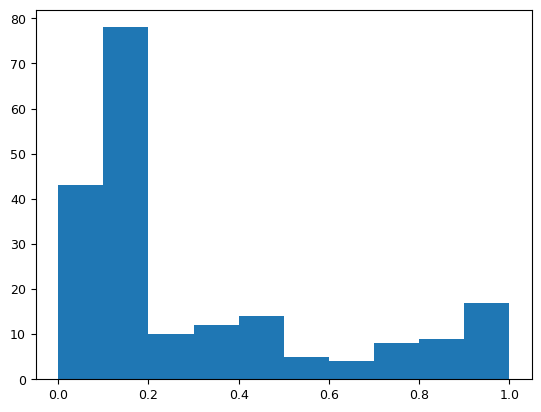

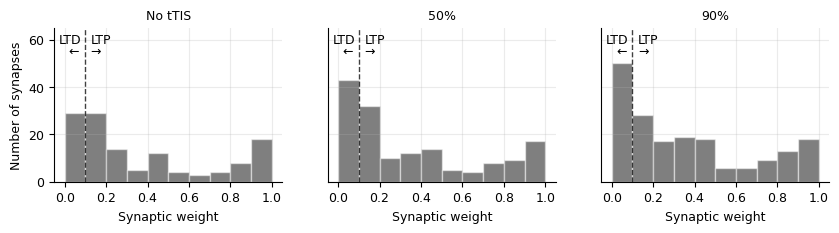

In [232]:
fig, axs = plt.subplots(nrows = 1, ncols = len(selected_stimulations), figsize = (10, 2), sharey = True)

for ax, stim in zip(axs, selected_stimulations.keys()):
  final = synapse_weights[stim].iloc[-1, :]
  final = final[ final != 0.1 ]

  bins = np.arange(0, 1.1, 0.1)
  ax.hist(final, bins = bins, edgecolor = "white", color = "black", alpha = 0.5)
  ax.set_title(selected_stimulations[stim])
  ax.set_xlabel("Synaptic weight")
  ax.set_ylabel("Number of synapses")
  ax.grid(alpha = 0.25)
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)

  ax.axvline(0.1, color="black", linestyle="--", linewidth=1, alpha = 0.75)
  ax.text(0.12, 0.9, "LTD", transform=ax.transAxes, ha="right")
  ax.text(0.11, 0.83, "←", transform=ax.transAxes, ha="right")

  ax.text(0.16, 0.9, "LTP", transform=ax.transAxes, ha="left")
  ax.text(0.16, 0.83, "→", transform=ax.transAxes, ha="left")
  ax.set_ylim(0, 65)

for ax in axs[1:3]:
  # ax.tick_params(axis="x", bottom=False, top=False, length=4)
  ax.tick_params(axis="y", left=False, right=False, length=4)
  ax.set_ylabel("")

plt.show()

/tmp/ipykernel_16117/2838500465.py:118: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for h in leg.legendHandles:


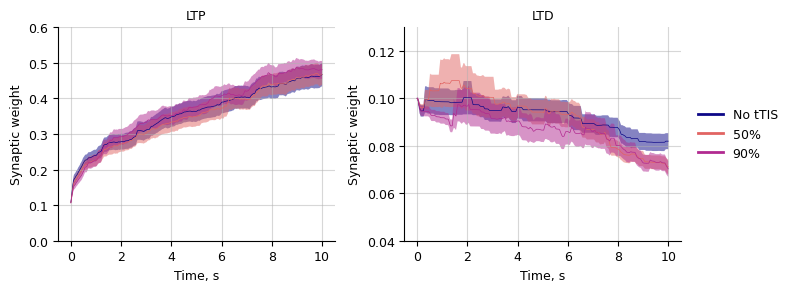

In [195]:
def moving_average(y, window):
  pad_left = window // 2
  pad_right = window - 1 - pad_left
  y_pad = np.pad(y, (pad_left, pad_right), mode="edge")
  kernel = np.ones(window) / window
  return np.convolve(y_pad, kernel, mode="valid")

window = 2500
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 3))

ax = axs[0]
for stim in selected_stimulations.keys():
  final = synapse_weights[stim].iloc[-1, :]
  color = colors[stim]

  is_ltp = np.where(final > 0.1)[0]
  is_ltd = np.where(final < 0.1)[0]

  ltp = synapse_weights[stim].iloc[:, is_ltp]

  dynamics = pd.DataFrame({
    "Time": ltp.index / 1000,
    "Mean": ltp.mean(axis = 1),
    "Error": ltp.std(axis = 1) / np.sqrt(ltp.shape[1])
  })

  smoothed_change = moving_average(dynamics.Mean.values, window)
  smoothed_error = moving_average(dynamics.Error.values, window)

  ax.plot(
    dynamics.Time,
    smoothed_change,
    linewidth = 0.5,
    label = label,
    color = color
  )

  ax.fill_between(
    dynamics.Time,
    smoothed_change - smoothed_error,
    smoothed_change + smoothed_error,
    alpha = 0.5,
    color = color,
    edgecolor = None
  )

  ax.set_xlabel("Time, s")
  ax.set_ylabel("Synaptic weight")

  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)

  ax.set_ylim(0, 0.6)
  ax.grid(alpha = 0.5)
  ax.autoscale(False)

axs[0].set_title("LTP")

ax = axs[1]
for stim in selected_stimulations.keys():
  final = synapse_weights[stim].iloc[-1, :]
  color = colors[stim]
  label = selected_stimulations[stim]

  is_ltp = np.where(final > 0.1)[0]
  is_ltd = np.where(final < 0.1)[0]

  ltp = synapse_weights[stim].iloc[:, is_ltd]

  dynamics = pd.DataFrame({
    "Time": ltp.index / 1000,
    "Mean": ltp.mean(axis = 1),
    "Error": ltp.std(axis = 1) / np.sqrt(ltp.shape[1])
  })

  smoothed_change = moving_average(dynamics.Mean.values, window)
  smoothed_error = moving_average(dynamics.Error.values, window)

  ax.plot(
    dynamics.Time,
    smoothed_change,
    linewidth = 0.5,
    label = label,
    color = color
  )

  ax.fill_between(
    dynamics.Time,
    smoothed_change - smoothed_error,
    smoothed_change + smoothed_error,
    alpha = 0.5,
    color = color,
    edgecolor = None
  )

  ax.set_xlabel("Time, s")
  ax.set_ylabel("Synaptic weight")

  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)

  ax.set_ylim(0.04, 0.13)
  ax.grid(alpha = 0.5)
  ax.autoscale(False)

axs[1].set_title("LTD")

handles, labels = axs[1].get_legend_handles_labels()

leg = axs[1].legend(
  handles,
  labels,
  loc="center left",
  bbox_to_anchor=(1.02, 0.5),
  frameon=False
)

for h in leg.legendHandles:
  if hasattr(h, "set_linewidth"):
    h.set_linewidth(2)
  if hasattr(h, "set_sizes"):
    h.set_sizes([50])

plt.tight_layout()
plt.show()

In [175]:
def get_mask(arr1, arr2):
  same_up = np.where((arr1 > 0.1) & (arr2 > 0.1))[0]
  same_down = np.where((arr1 < 0.1) & (arr2 < 0.1))[0]

  same_all = np.concatenate([same_up, same_down])
  same_all = np.sort(same_all)

  mask = ~np.isin(np.arange(0, 200), same_all)

  return np.where(mask, "red", "black")

from scipy.stats import pearsonr

def add_corr(ax, x, y):
    r, p = pearsonr(x, y)

    ax.text(
        0.05, 0.95,
        f"r = {r:.2f}\np = {p:.1e}",
        transform=ax.transAxes,
        va="top"
    )

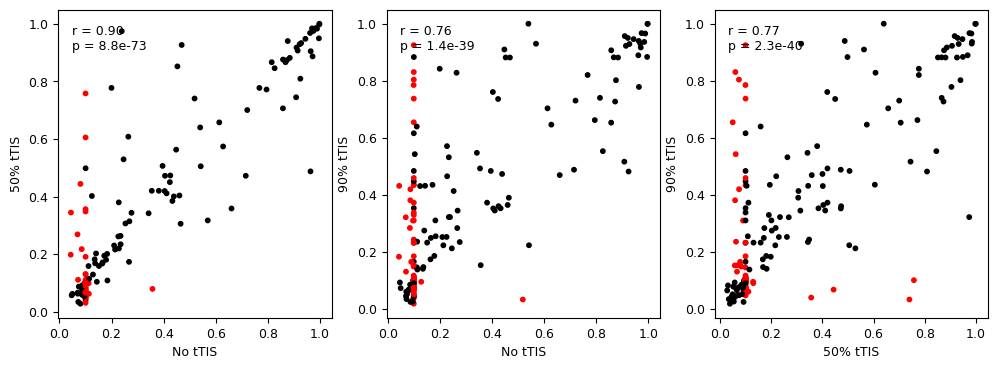

In [179]:
final_ti_50 = synapse_weights["1000_5_0.5"].iloc[-1, :]
final_ti_90 = synapse_weights["1000_5_0.9"].iloc[-1, :]
final_ti_no = synapse_weights["noTI"].iloc[-1, :]

fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 4))

axs[0].scatter(
  final_ti_no,
  final_ti_50,
  s = 10,
  c = get_mask(final_ti_no, final_ti_50)
)

add_corr(axs[0], final_ti_no, final_ti_50)

axs[0].set_xlabel("No tTIS")
axs[0].set_ylabel("50% tTIS")

axs[1].scatter(
  final_ti_no,
  final_ti_90,
  s = 10,
  c = get_mask(final_ti_no, final_ti_90)
)

add_corr(axs[1], final_ti_no, final_ti_90)

axs[1].set_xlabel("No tTIS")
axs[1].set_ylabel("90% tTIS")

axs[2].scatter(
  final_ti_50,
  final_ti_90,
  s = 10,
  c = get_mask(final_ti_50, final_ti_90)
)

add_corr(axs[2], final_ti_50, final_ti_90)

axs[2].set_xlabel("50% tTIS")
axs[2].set_ylabel("90% tTIS")

plt.show()